In [2]:
pip install pandas numpy seaborn matplotlib scikit-learn experta joblib streamlit jupyter


     ---------------------------------------- 10.0/10.0 MB 3.2 MB/s eta 0:00:00
     -------------------------------------- 293.3/293.3 kB 3.0 MB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 3.2 MB/s eta 0:00:00
     ---------------------------------------- 7.1/7.1 MB 3.2 MB/s eta 0:00:00
     -------------------------------------- 302.2/302.2 kB 3.1 MB/s eta 0:00:00
     ---------------------------------------- 8.9/8.9 MB 2.0 MB/s eta 0:00:00
     -------------------------------------- 510.5/510.5 kB 2.5 MB/s eta 0:00:00
     ---------------------------------------- 2.5/2.5 MB 2.6 MB/s eta 0:00:00
     -------------------------------------- 104.1/104.1 kB 3.0 MB/s eta 0:00:00
     -------------------------------------- 965.4/965.4 kB 2.7 MB/s eta 0:00:00
     ---------------------------------------- 55.8/55.8 kB 3.0 MB/s eta 0:00:00
     ---------------------------------------- 34.1/34.1 MB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Prepa

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.feature_selection import SelectKBest, f_classif
from experta import *
import joblib
import streamlit as st
import warnings
warnings.filterwarnings('ignore')



In [6]:
df = pd.read_csv(r'C:\Users\ok\Desktop\heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1.0,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0.0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0.0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0.0,159,0,0.0,2,0,2,1


In [9]:
print(df.isnull().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [10]:
df.fillna(df.median(), inplace=True)


In [11]:
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [12]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"Total: {df.isnull().sum().sum()}")


Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Total: 0


In [28]:

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = MinMaxScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
print("✓ Normalization completed")
print(df[numerical_features].head())

✓ Normalization completed
        age  trestbps      chol   thalach   oldpeak
0  0.479167  0.292453  0.196347  0.740458  0.161290
1  0.500000  0.433962  0.175799  0.641221  0.500000
2  0.854167  0.481132  0.109589  0.412214  0.419355
3  0.666667  0.509434  0.175799  0.687023  0.000000
4  0.687500  0.415094  0.383562  0.267176  0.306452


In [27]:
df = pd.get_dummies(df, drop_first=True)

print("✓ Encoding completed")
print(df.head())


✓ Encoding completed
        age  trestbps      chol   thalach   oldpeak  target  sex_1  cp_1  \
0  0.479167  0.292453  0.196347  0.740458  0.161290       0      1     0   
1  0.500000  0.433962  0.175799  0.641221  0.500000       0      1     0   
2  0.854167  0.481132  0.109589  0.412214  0.419355       0      1     0   
3  0.666667  0.509434  0.175799  0.687023  0.000000       0      1     0   
4  0.687500  0.415094  0.383562  0.267176  0.306452       0      0     0   

   cp_2  cp_3  ...  exang_1  slope_1  slope_2  ca_1  ca_2  ca_3  ca_4  thal_1  \
0     0     0  ...        0        0        1     0     1     0     0       0   
1     0     0  ...        1        0        0     0     0     0     0       0   
2     0     0  ...        1        0        0     0     0     0     0       0   
3     0     0  ...        0        0        1     1     0     0     0       0   
4     0     0  ...        0        1        0     0     0     1     0       0   

   thal_2  thal_3  
0       0      

In [29]:
# Calculate correlation with target variable
correlation = df.corr()['target'].sort_values(ascending=False)

print("Feature correlation with target:")
print(correlation)

Feature correlation with target:
target         1.000000
thal_2         0.523961
thalach        0.423188
slope_2        0.389233
cp_2           0.319507
cp_1           0.255276
restecg_1.0    0.178149
cp_3           0.089234
ca_4           0.085628
fbs_1         -0.038965
restecg_2.0   -0.076601
chol          -0.099351
thal_1        -0.100632
trestbps      -0.139704
ca_3          -0.206333
age           -0.229106
ca_1          -0.234260
ca_2          -0.275346
sex_1         -0.279398
slope_1       -0.349395
oldpeak       -0.437571
exang_1       -0.437950
thal_3        -0.481761
Name: target, dtype: float64


In [30]:
# Save as CSV
df.to_csv('cleaned_data.csv', index=False)

print("✓ Cleaned data saved as 'cleaned_data.csv'")

✓ Cleaned data saved as 'cleaned_data.csv'


In [31]:
# Statistical summary of key features
print("\n📊 STATISTICAL SUMMARY")
print("=" * 50)
print(df.describe())

# For specific heart disease features
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
existing_features = [f for f in key_features if f in df.columns]

print("\n📊 KEY FEATURES STATISTICS:")
print(df[existing_features].describe())

# Distribution statistics
print("\n📊 DISTRIBUTION INFORMATION:")
for col in existing_features:
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std: {df[col].std():.2f}")
    print(f"  Skewness: {df[col].skew():.2f}")


📊 STATISTICAL SUMMARY
               age     trestbps         chol      thalach      oldpeak  \
count  1022.000000  1022.000000  1022.000000  1022.000000  1022.000000   
mean      0.529660     0.354789     0.274113     0.596368     0.172669   
std       0.189225     0.165463     0.117898     0.175867     0.189615   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.395833     0.245283     0.194064     0.465649     0.000000   
50%       0.562500     0.339623     0.260274     0.618321     0.129032   
75%       0.666667     0.433962     0.340183     0.725191     0.290323   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

            target        sex_1         cp_1         cp_2         cp_3  ...  \
count  1022.000000  1022.000000  1022.000000  1022.000000  1022.000000  ...   
mean      0.513699     0.694716     0.163405     0.277886     0.074364  ...   
std       0.500057     0.460753     0.369916     0.448176     0.262491  .

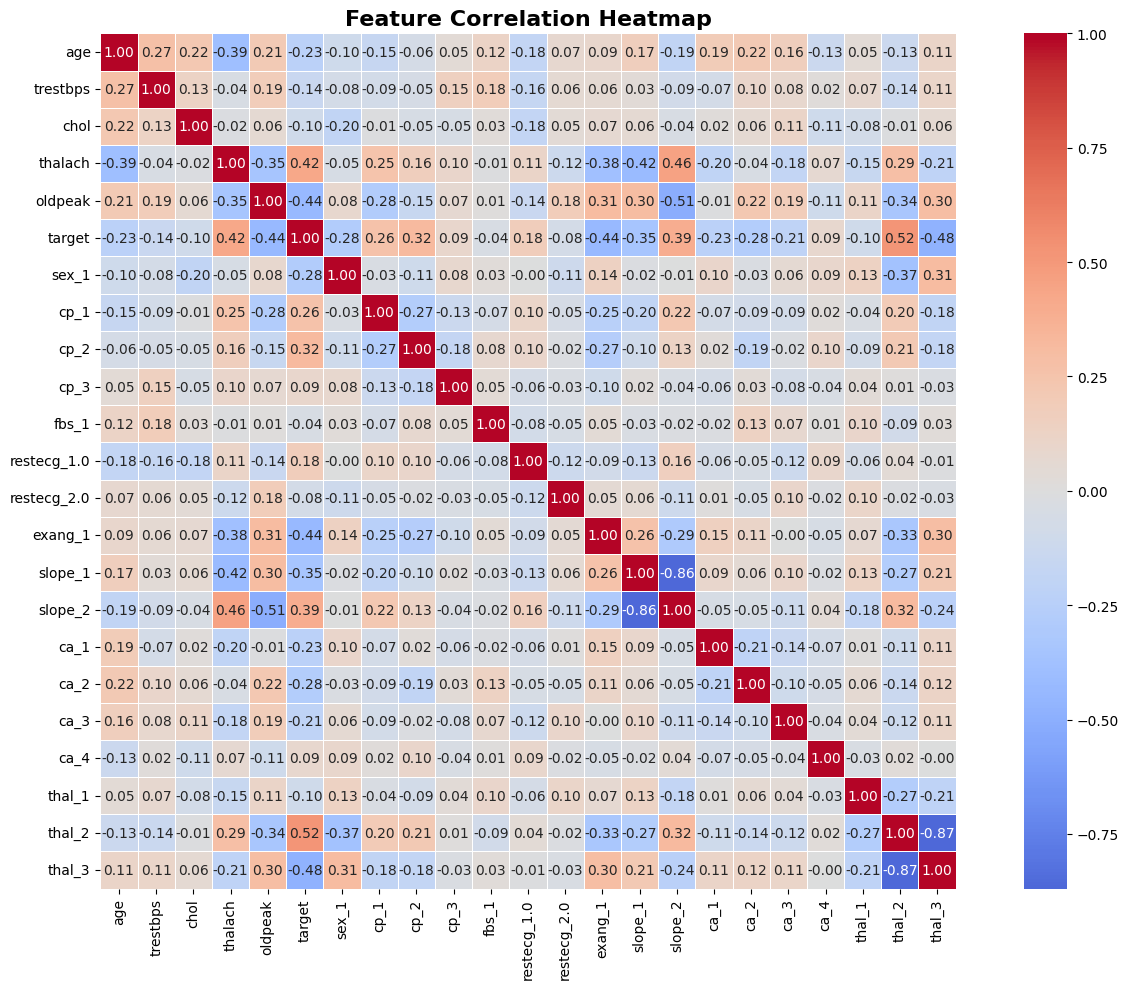

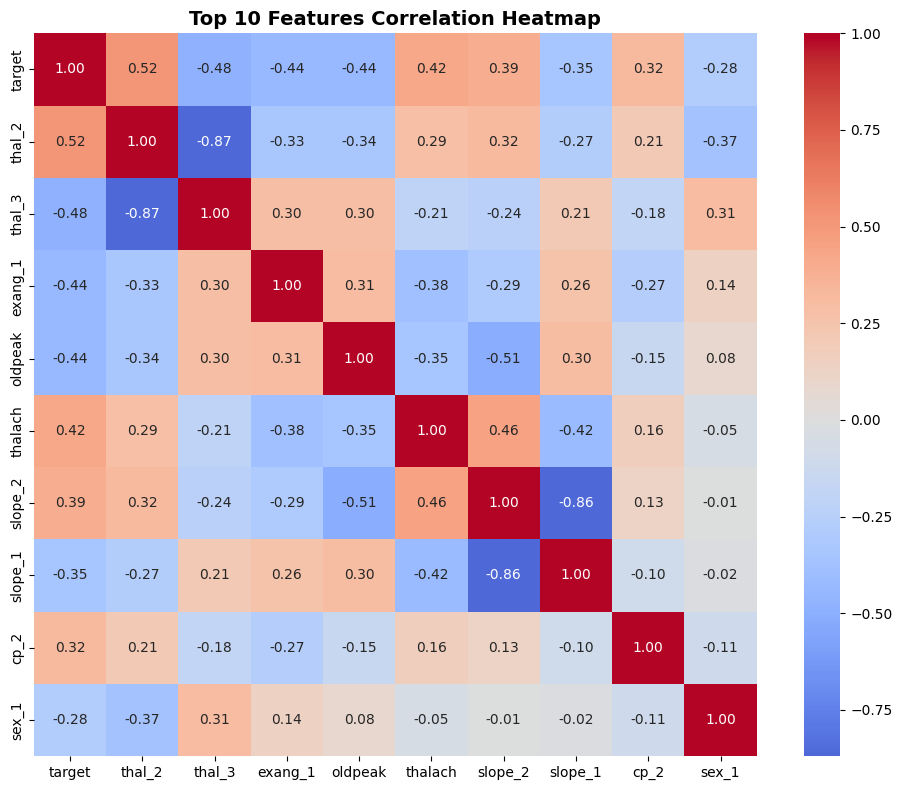

In [32]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Focused heatmap with top features
if 'target' in df.columns:
    top_features = df.corr()['target'].abs().sort_values(ascending=False).head(10).index.tolist()
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True)
    plt.title('Top 10 Features Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

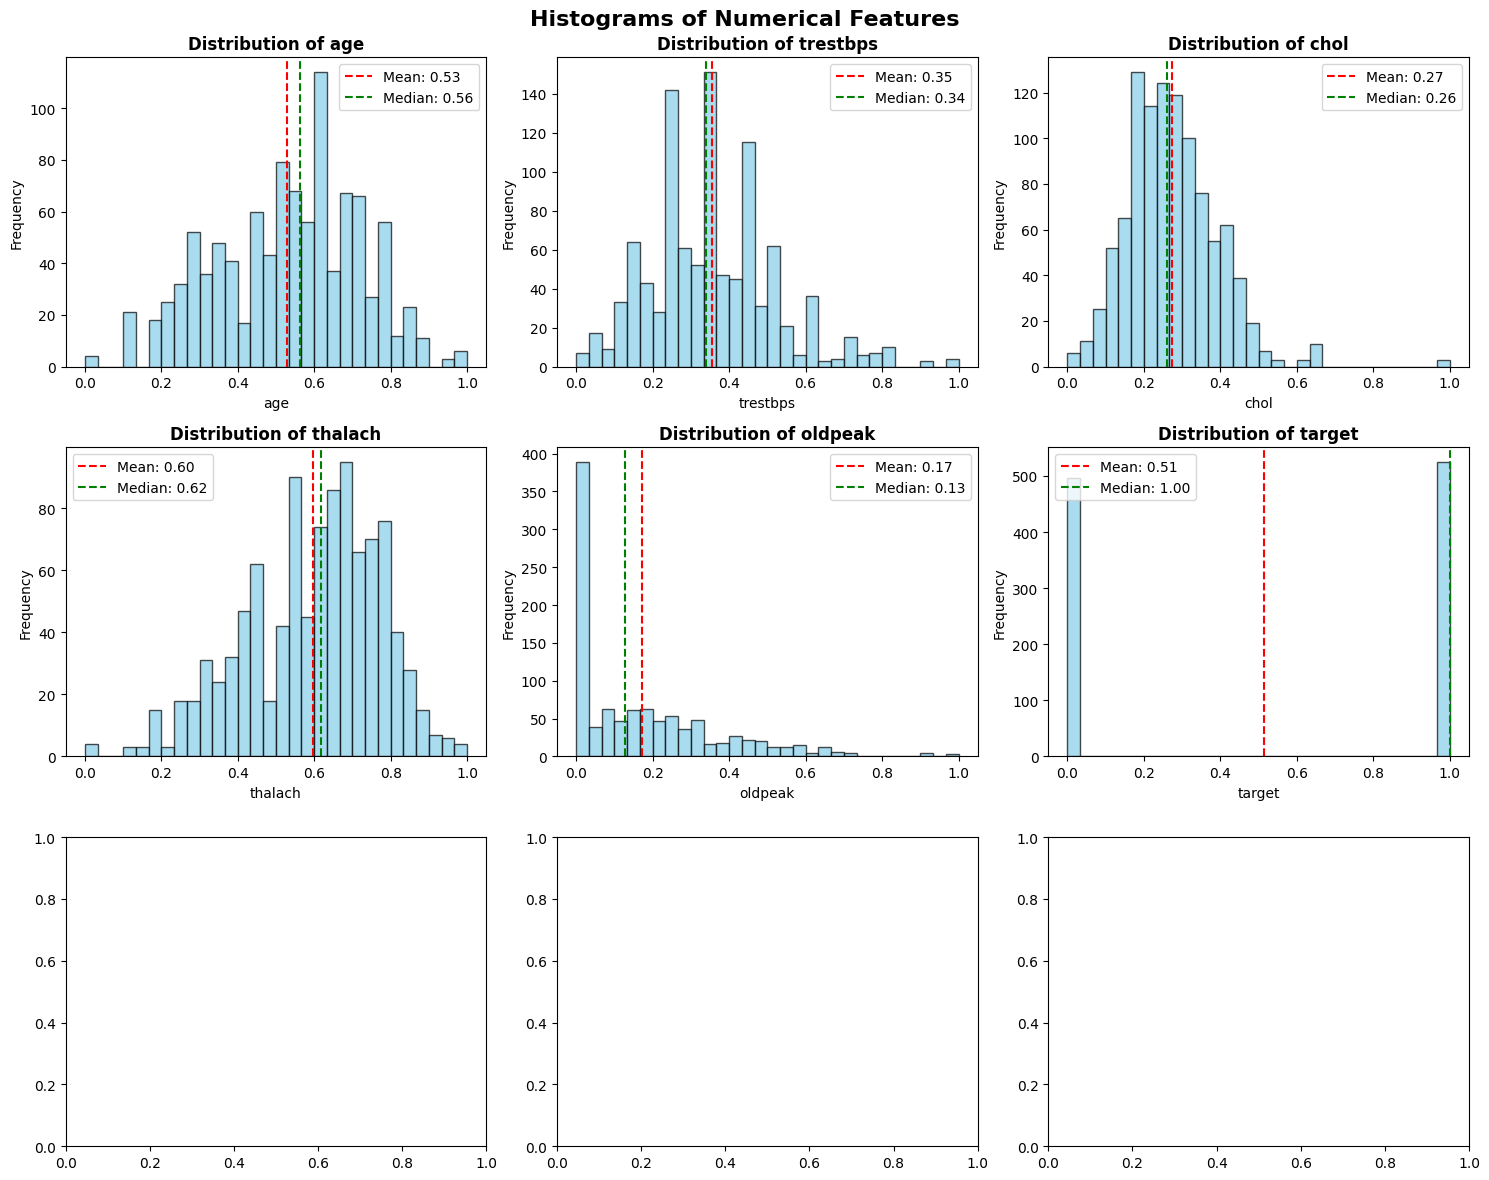

age: 0 outliers detected
trestbps: 30 outliers detected
chol: 16 outliers detected
thalach: 4 outliers detected
oldpeak: 7 outliers detected


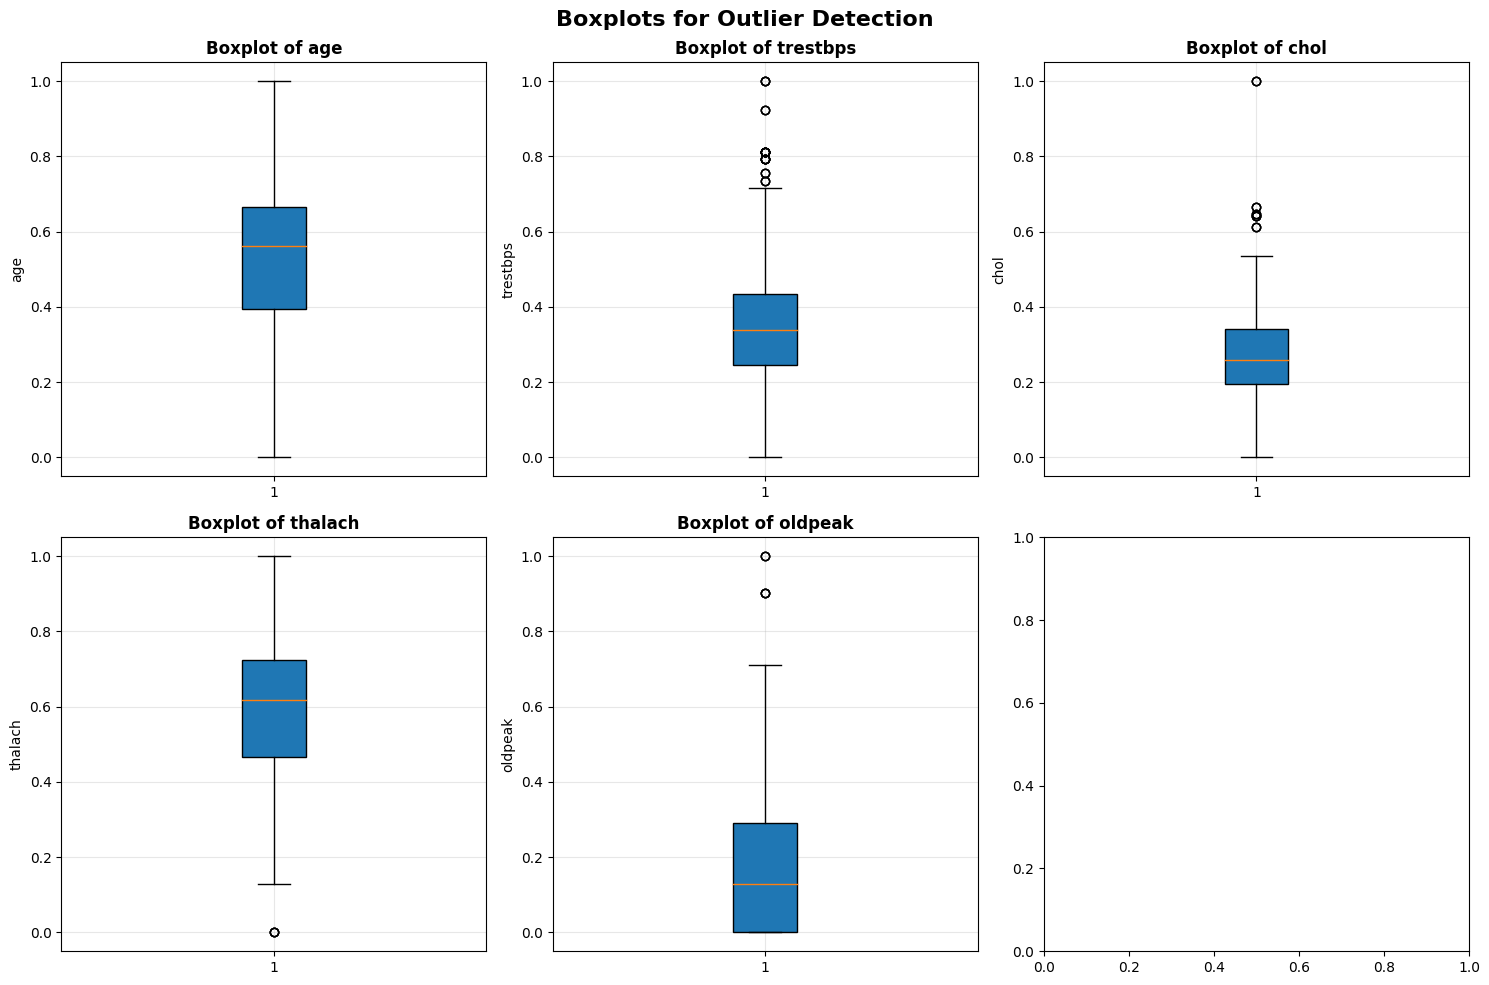

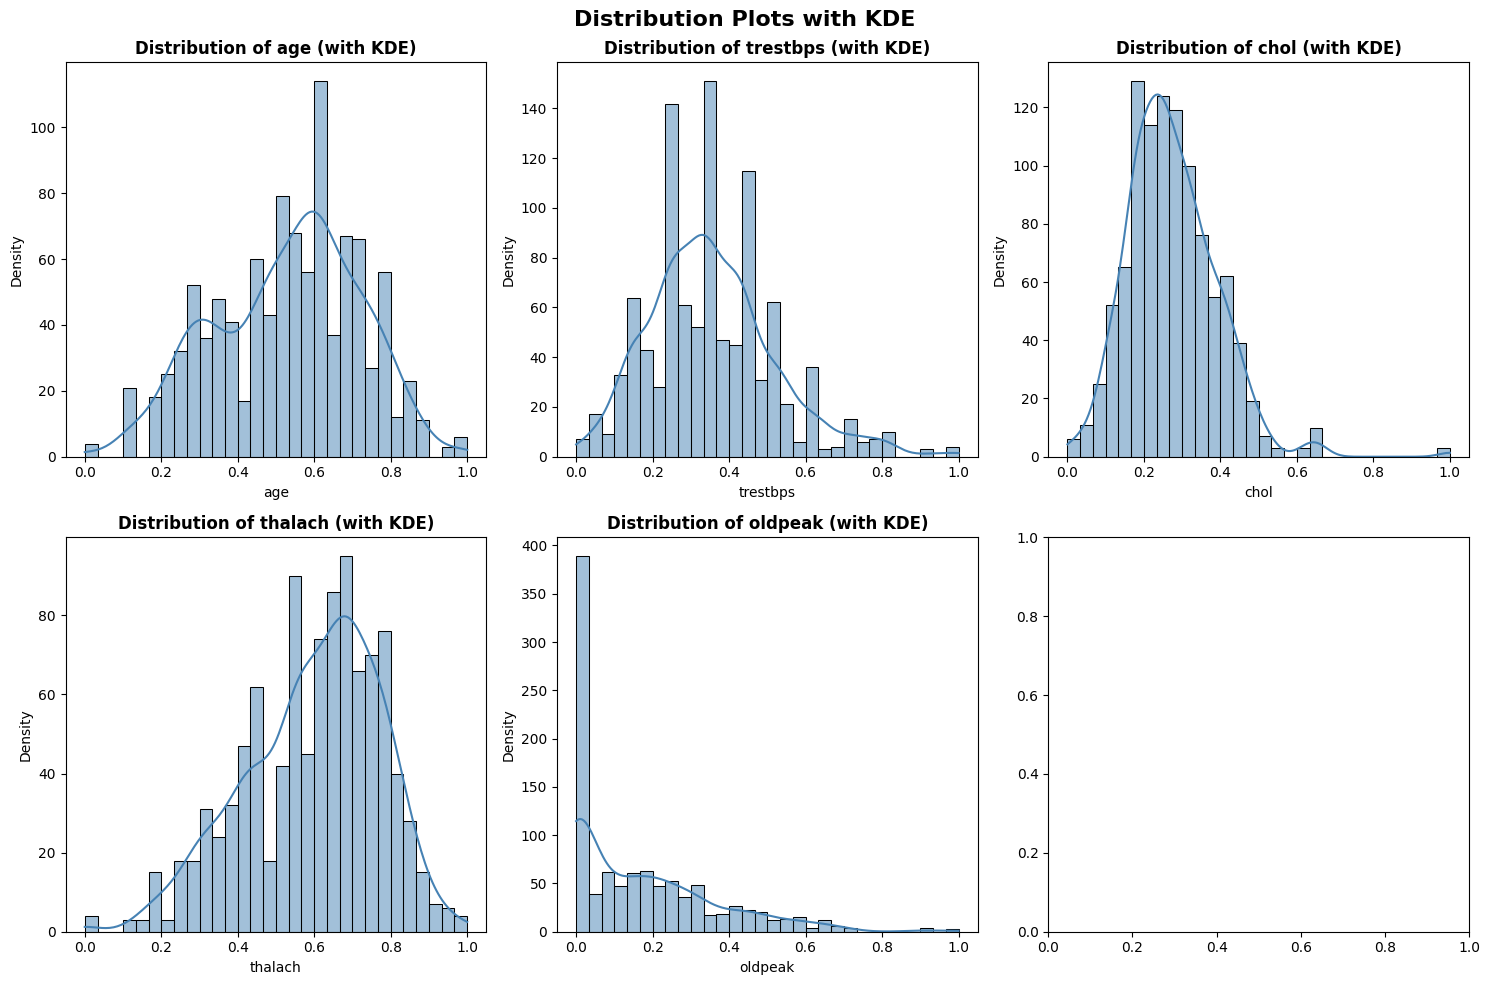

In [33]:
# Histograms for all numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols[:9]):  # First 9 numerical columns
    axes[i].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[i].legend()

plt.suptitle('Histograms of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# Boxplots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(existing_features[:6]):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)
    
    # Calculate outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

plt.suptitle('Boxplots for Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# Distribution with KDE
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(existing_features[:6]):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribution of {col} (with KDE)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.suptitle('Distribution Plots with KDE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_kde.png', dpi=300, bbox_inches='tight')
plt.show()

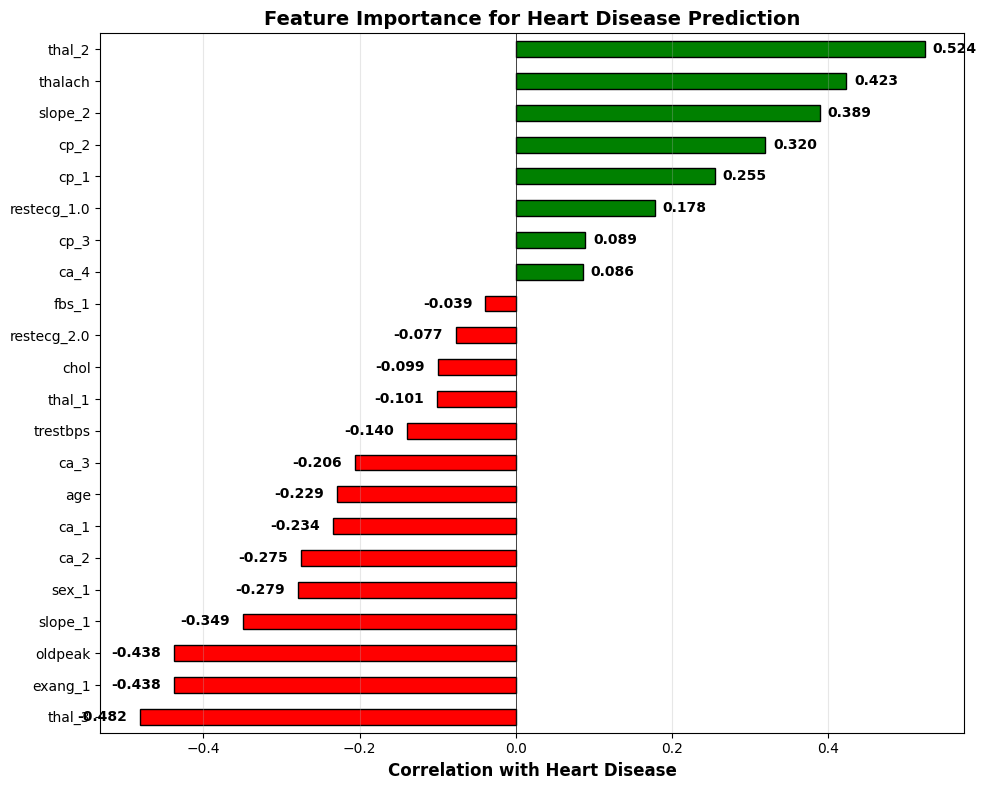


📊 FEATURE IMPORTANCE RANKING
1. thal_2: 0.524 (Positive)
2. thal_3: -0.482 (Negative)
3. exang_1: -0.438 (Negative)
4. oldpeak: -0.438 (Negative)
5. thalach: 0.423 (Positive)
6. slope_2: 0.389 (Positive)
7. slope_1: -0.349 (Negative)
8. cp_2: 0.320 (Positive)
9. sex_1: -0.279 (Negative)
10. ca_2: -0.275 (Negative)
11. cp_1: 0.255 (Positive)
12. ca_1: -0.234 (Negative)
13. age: -0.229 (Negative)
14. ca_3: -0.206 (Negative)
15. restecg_1.0: 0.178 (Positive)
16. trestbps: -0.140 (Negative)
17. thal_1: -0.101 (Negative)
18. chol: -0.099 (Negative)
19. cp_3: 0.089 (Positive)
20. ca_4: 0.086 (Positive)
21. restecg_2.0: -0.077 (Negative)
22. fbs_1: -0.039 (Negative)


In [34]:
# Feature importance based on correlation with target
if 'target' in df.columns:
    # Calculate correlations
    correlations = df.corr()['target'].drop('target').sort_values(ascending=True)
    
    # Create horizontal bar plot
    plt.figure(figsize=(10, 8))
    colors = ['red' if x < 0 else 'green' for x in correlations.values]
    correlations.plot(kind='barh', color=colors, edgecolor='black')
    plt.xlabel('Correlation with Heart Disease', fontsize=12, fontweight='bold')
    plt.title('Feature Importance for Heart Disease Prediction', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    # Add value labels
    for i, v in enumerate(correlations.values):
        plt.text(v + 0.01 if v > 0 else v - 0.08, i, f'{v:.3f}', 
                va='center', fontweight='bold')
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print feature ranking
    print("\n📊 FEATURE IMPORTANCE RANKING")
    print("=" * 50)
    for i, (feature, corr) in enumerate(correlations.abs().sort_values(ascending=False).items(), 1):
        direction = "Positive" if correlations[feature] > 0 else "Negative"
        print(f"{i}. {feature}: {correlations[feature]:.3f} ({direction})")

In [36]:
class HeartDiseaseExpert(KnowledgeEngine):
    
    @Rule(Fact(age=P(lambda x: x > 50)) & Fact(chol=P(lambda x: x > 240)))
    def rule1(self):
        self.risk = "High"
        print("⚠️ High Risk: Age > 50 and Cholesterol > 240")
    
    @Rule(Fact(bp=P(lambda x: x > 140)) & Fact(smoking="yes"))
    def rule2(self):
        self.risk = "High"
        print("⚠️ High Risk: BP > 140 and Smoking")
    
    @Rule(Fact(exercise="regular") & Fact(bmi=P(lambda x: x < 25)))
    def rule3(self):
        if not hasattr(self, 'risk') or self.risk != "High":
            self.risk = "Low"
            print("✓ Low Risk: Regular exercise and healthy BMI")
    
    @Rule(Fact(diabetes="yes") & Fact(chol=P(lambda x: x > 200)))
    def rule4(self):
        self.risk = "High"
        print("⚠️ High Risk: Diabetes and High Cholesterol")
    
    @Rule(Fact(age=P(lambda x: x > 40)) & Fact(family_history="yes"))
    def rule5(self):
        if not hasattr(self, 'risk') or self.risk != "High":
            self.risk = "Moderate"
            print("⚠️ Moderate Risk: Age > 40 and Family History")
    
    @Rule(Fact(bp=P(lambda x: x < 120)) & Fact(exercise="regular"))
    def rule6(self):
        if not hasattr(self, 'risk'):
            self.risk = "Low"
            print("✓ Low Risk: Normal BP and regular exercise")
    
    @Rule(Fact(chol=P(lambda x: x > 220)) & Fact(smoking="yes"))
    def rule7(self):
        self.risk = "High"
        print("⚠️ High Risk: High Cholesterol and Smoking")
    
    @Rule(Fact(bmi=P(lambda x: x > 30)) & Fact(exercise="never"))
    def rule8(self):
        if not hasattr(self, 'risk') or self.risk != "High":
            self.risk = "Moderate"
            print("⚠️ Moderate Risk: Obese and Sedentary")
    
    @Rule(Fact(age=P(lambda x: x < 35)) & Fact(exercise="regular") & Fact(smoking="no"))
    def rule9(self):
        if not hasattr(self, 'risk'):
            self.risk = "Low"
            print("✓ Low Risk: Young, active, non-smoker")
    
    @Rule(Fact(chest_pain=P(lambda x: x > 2)) & Fact(bp=P(lambda x: x > 130)))
    def rule10(self):
        self.risk = "High"
        print("⚠️ High Risk: Chest pain and High BP")

# Simple inputs
print("\n=== HEART DISEASE RISK ASSESSMENT ===\n")

age = int(input("Age: "))
chol = int(input("Cholesterol: "))
bp = int(input("Blood Pressure: "))
smoking = input("Smoker? (yes/no): ").lower()
exercise = input("Exercise regularly? (yes/no): ").lower()
bmi = float(input("BMI: "))
diabetes = input("Diabetes? (yes/no): ").lower()
family_history = input("Family history? (yes/no): ").lower()
chest_pain = int(input("Chest pain type (1-4): "))

exercise = "regular" if exercise == "yes" else "never"

# Run
engine = HeartDiseaseExpert()
engine.reset()
engine.declare(Fact(age=age))
engine.declare(Fact(chol=chol))
engine.declare(Fact(bp=bp))
engine.declare(Fact(smoking=smoking))
engine.declare(Fact(exercise=exercise))
engine.declare(Fact(bmi=bmi))
engine.declare(Fact(diabetes=diabetes))
engine.declare(Fact(family_history=family_history))
engine.declare(Fact(chest_pain=chest_pain))

print("\n" + "=" * 40)
engine.run()

if hasattr(engine, 'risk'):
    print(f"\n🎯 FINAL RISK: {engine.risk.upper()}")
else:
    print("\n🎯 FINAL RISK: MODERATE")
print("=" * 40)



=== HEART DISEASE RISK ASSESSMENT ===

Age: 40
Cholesterol: 250
Blood Pressure: 140
Smoker? (yes/no): yes
Exercise regularly? (yes/no): no
BMI: 24.9
Diabetes? (yes/no): yes
Family history? (yes/no): yes
Chest pain type (1-4): 4

⚠️ High Risk: Chest pain and High BP
⚠️ High Risk: Diabetes and High Cholesterol
⚠️ High Risk: High Cholesterol and Smoking

🎯 FINAL RISK: HIGH


In [42]:
os.makedirs('models', exist_ok=True)
# Load and split
df = pd.read_csv('cleaned_data.csv')
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

# Save
joblib.dump(model, 'models/decision_tree_model.pkl')
print("Model saved!")




Accuracy: 0.8488
Model saved!
